In [1]:
data_dir = '/home/mjehangir/glioma_manuscript/manuscript_data/'

In [2]:
setwd(data_dir)

In [3]:
# Load necessary libraries
library(openxlsx)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package

In [34]:
# Load the data from your txt file
file_path <- "/scratch/mjehangir/Glioma_project/severus/severus_out/severus_merged_svs.bed"
data <- read.table(file_path, header = TRUE, sep = "\t")
head(data)

,chr,start,end,size,type,sample
,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,chr1,243491,243588,97,DEL,2436A_run3
2,chr1,295706,295707,1,INS,2436A_run3
3,chr1,305823,305824,1,INS,2436A_run3
4,chr1,334498,334590,92,DEL,2436A_run3
5,chr1,364366,364367,1,INS,2436A_run3
6,chr1,405456,407204,1748,DEL,2436A_run3


In [51]:
library(dplyr)

# Step 1: Create a unique SV ID
data <- data %>%
  mutate(SV_id = paste(chr, start, end, type, sep = "_"))

# Step 2: Count how many unique samples each SV appears in
sv_sample_counts <- data %>%
  distinct(SV_id, sample) %>%
  group_by(SV_id) %>%
  summarise(shared_in = n(), .groups = "drop")

# Step 3: Filter SVs shared across all 20 samples
shared_svs <- sv_sample_counts %>%
  filter(shared_in == 20)

# Step 4: Get full details of shared SVs including size
shared_sv_list <- data %>%
  filter(SV_id %in% shared_svs$SV_id) %>%
  distinct(SV_id, chr, start, end, size, type)

# Step 5: Print the result
print(shared_sv_list)


                            SV_id   chr     start       end size type
1        chr1_6282283_6282590_DEL  chr1   6282283   6282590  307  DEL
2      chr1_18101240_18101296_DEL  chr1  18101240  18101296   56  DEL
3      chr1_23839493_23839824_DEL  chr1  23839493  23839824  331  DEL
4      chr1_40366272_40366273_INS  chr1  40366272  40366273    1  INS
5      chr1_50443898_50444209_DEL  chr1  50443898  50444209  311  DEL
6      chr1_69824823_69825141_DEL  chr1  69824823  69825141  318  DEL
7      chr1_87663390_87663391_INS  chr1  87663390  87663391    1  INS
8      chr1_87668944_87669066_DEL  chr1  87668944  87669066  122  DEL
9      chr1_91613370_91613684_DEL  chr1  91613370  91613684  314  DEL
10   chr1_108516775_108516776_INS  chr1 108516775 108516776    1  INS
11   chr1_128909019_128909020_INS  chr1 128909019 128909020    1  INS
12   chr1_155013336_155013337_INS  chr1 155013336 155013337    1  INS
13   chr1_155092708_155092709_INS  chr1 155092708 155092709    1  INS
14   chr1_162463623_

In [9]:

data <- data %>%
  dplyr::rename(filename = sample)
head(data)

,chr,start,end,size,type,filename
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>
1,chr1,243491,243588,97,DEL,2436A_run3
2,chr1,295706,295707,1,INS,2436A_run3
3,chr1,305823,305824,1,INS,2436A_run3
4,chr1,334498,334590,92,DEL,2436A_run3
5,chr1,364366,364367,1,INS,2436A_run3
6,chr1,405456,407204,1748,DEL,2436A_run3


In [32]:
data <- data %>%
  mutate(size = abs(as.numeric(end) - as.numeric(start))) %>%  # Recalculate size in base pairs
  filter(size > 0)  # Only keep rows where the size is greater than 0

# Show the first few rows of the data
head(data)

# Save to a tab-separated file
#write.table(data, "/home/mjehangir/data_analysis/glioma_project_data_analysis/glioma_project/SV_analysis/sniffles_merged_all_samples_SVs_v8.txt", 
            #sep = "\t", row.names = FALSE)


,chr,start,end,size,type,filename
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>
1,chr1,243491,243588,97,DEL,2436A_run3
2,chr1,295706,295707,1,INS,2436A_run3
3,chr1,305823,305824,1,INS,2436A_run3
4,chr1,334498,334590,92,DEL,2436A_run3
5,chr1,364366,364367,1,INS,2436A_run3
6,chr1,405456,407204,1748,DEL,2436A_run3


`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


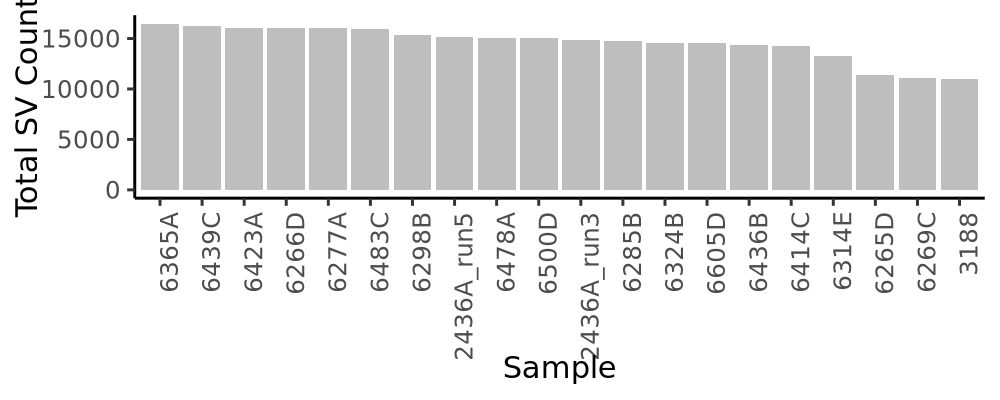

`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


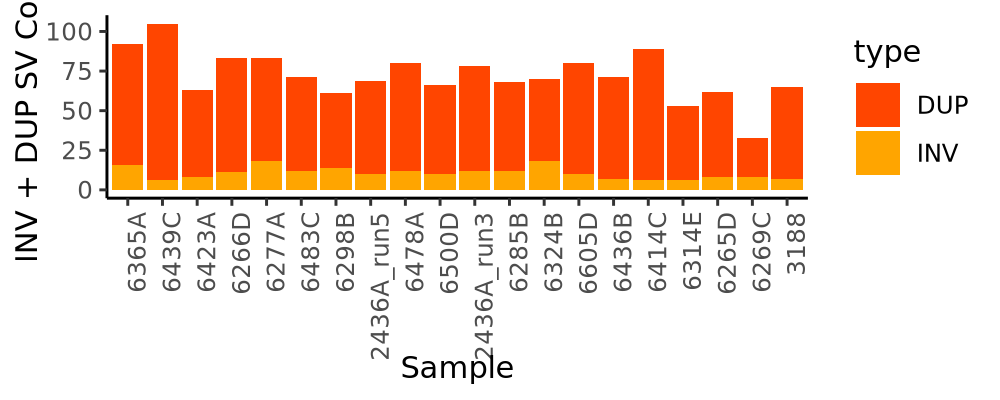

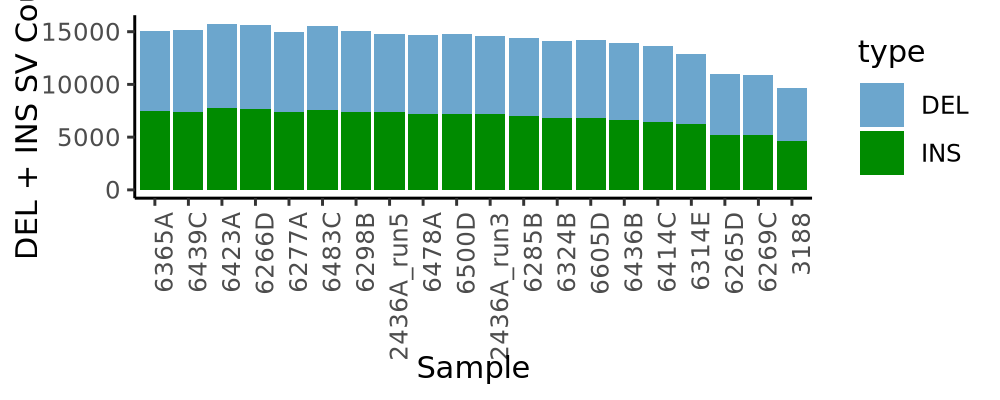

In [10]:

# Step 1: Filter the data to keep only chromosomes from chr1 to chr22
data <- data %>%
  filter(chr %in% paste0("chr", 1:22))  # Filter out chrX, chrY, chrM

# Step 2: Total SVs per sample bar plot (raw count, ordered descending)
total_SVs <- data %>%
  group_by(filename) %>%
  summarize(Total_SV = n())  # Count number of SVs per sample

# Sort samples by total SV count (descending order)
sorted_samples <- total_SVs %>%
  arrange(desc(Total_SV)) %>%
  pull(filename)

options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

# Barplot for total SV count per sample (ordered descending)
ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# Step 3: Stacked bar plot by SV types (combining INV + DUP and DEL + INS into separate plots)
# INV + DUP combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity


# DEL + INS combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

In [11]:
head(total_SVs)

filename,Total_SV
<chr>,<int>
2436A_run3,14868
2436A_run5,15132
3188,10984
6265D,11378
6266D,16070
6269C,11082


In [12]:
total_svs_sorted <- total_SVs %>%
  arrange(desc(Total_SV))

print(total_svs_sorted)

# A tibble: 20 × 2
   filename   Total_SV
   <chr>         <int>
 1 6365A         16486
 2 6439C         16278
 3 6423A         16088
 4 6266D         16070
 5 6277A         16054
 6 6483C         15990
 7 6298B         15395
 8 2436A_run5    15132
 9 6478A         15099
10 6500D         15032
11 2436A_run3    14868
12 6285B         14774
13 6324B         14542
14 6605D         14538
15 6436B         14334
16 6414C         14301
17 6314E         13271
18 6265D         11378
19 6269C         11082
20 3188          10984


In [13]:
library(ggplot2)
library(dplyr)

# Assuming 'data' contains the necessary data and 'sorted_samples' is already defined

# Step 1: Total SV Count per Sample Plot (ordered descending)
total_SV_plot <- ggplot(total_SVs, aes(x = factor(filename, levels = sorted_samples), y = Total_SV)) +
  geom_bar(stat = "identity", fill = "grey") +
  labs(x = "Sample", y = "Total SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("Total_SV_Count_v2.pdf", plot = total_SV_plot, height = 6, width = 10)  # Save as PDF with v2 naming

# Step 2: INV + DUP Combined Plot
sv_types_INV_DUP <- data %>%
  filter(type %in% c("INV", "DUP")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of INV and DUP SVs per sample

INV_DUP_plot <- ggplot(sv_types_INV_DUP, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("INV" = "orange", "DUP" = "orangered")) +
  labs(x = "Sample", y = "INV + DUP SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("INV_DUP_SV_Count_v2.pdf", plot = INV_DUP_plot, height = 6, width = 10)  # Save as PDF with v2 naming

# Step 3: DEL + INS Combined Plot
sv_types_DEL_INS <- data %>%
  filter(type %in% c("DEL", "INS")) %>%
  group_by(filename, type) %>%
  summarize(SV_count_type = n())  # Count number of DEL and INS SVs per sample

DEL_INS_plot <- ggplot(sv_types_DEL_INS, aes(x = factor(filename, levels = sorted_samples), y = SV_count_type, fill = type)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("DEL" = "skyblue3", "INS" = "green4")) +
  labs(x = "Sample", y = "DEL + INS SV Count") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate x-axis labels for clarity

#ggsave("DEL_INS_SV_Count_v2.pdf", plot = DEL_INS_plot, height = 6, width = 10)  # Save as PDF with v2 naming


`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'filename'. You can override using the
`.groups` argument.


In [14]:
library(scales)

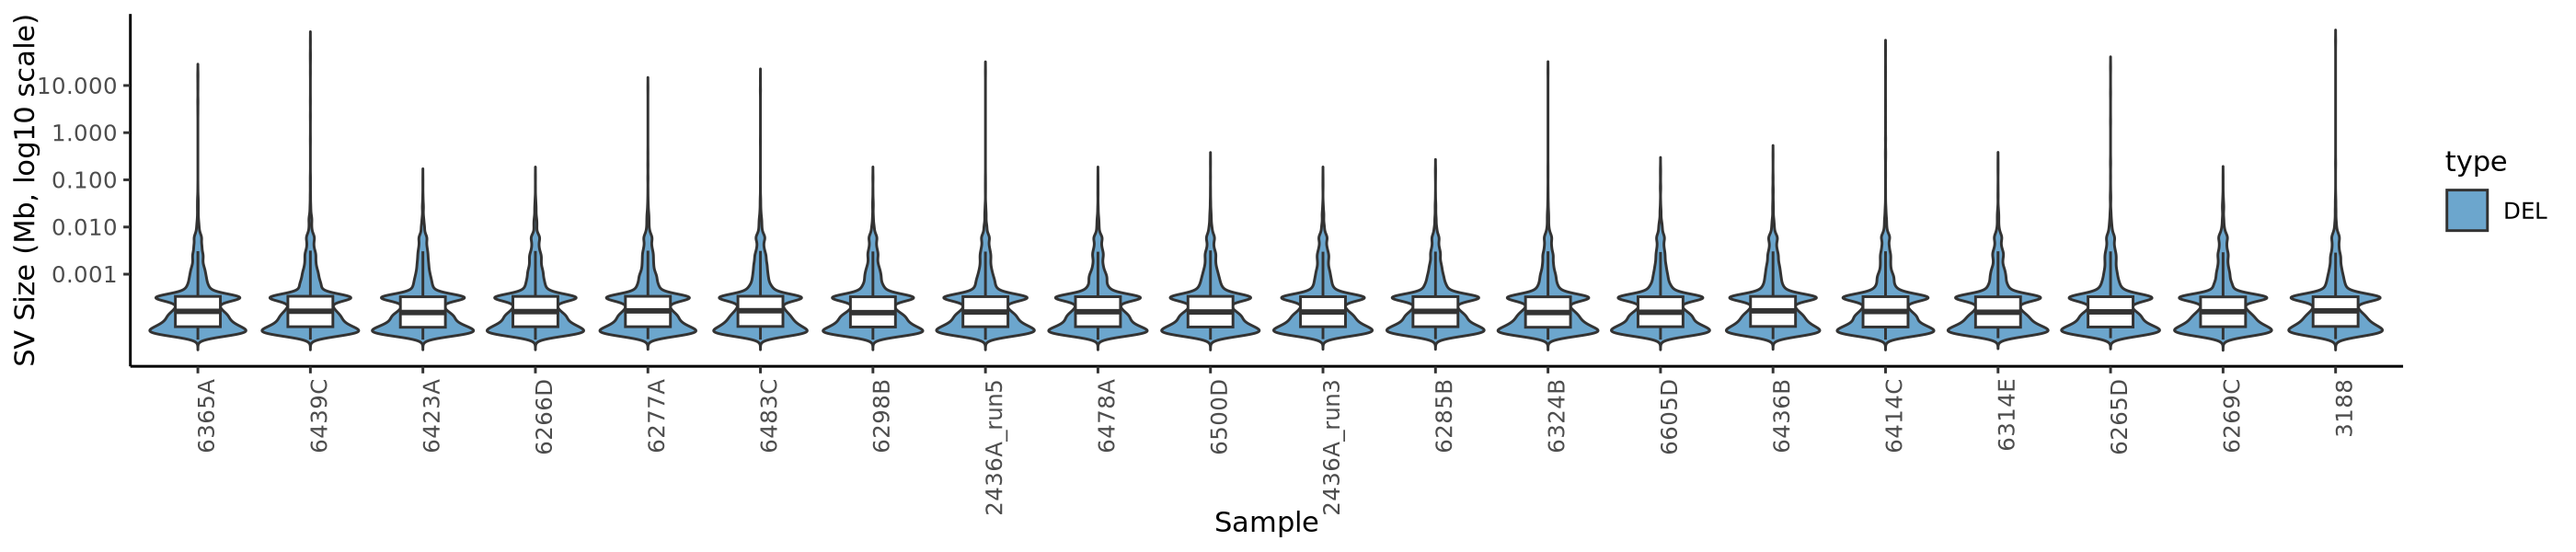

In [15]:

options(repr.plot.width = 14, repr.plot.height = 3, repr.plot.res = 200)

del_violin_plot<-ggplot(data %>% filter(type == "DEL"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1, 10), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DEL" = "skyblue3")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
print(del_violin_plot)
# Save the plot to the specified directory
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/DEL_SV_Size_violin_v2.pdf", plot = del_violin_plot, height = 6, width = 14)


In [16]:
dup_violin_plot<-ggplot(data %>% filter(type == "DUP"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("DUP" = "orangered")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/DUP_SV_Size_violin_v2.pdf", plot = dup_violin_plot, height = 6, width = 14)


In [19]:
inv_violin_plot<-ggplot(data %>% filter(type == "INV"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 1) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.1, 1, 10, 100), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INV" = "orange")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INV_SV_Size_violin_v2.pdf", plot = inv_violin_plot, height = 6, width = 14)


In [20]:
ins_violin_plot<-ggplot(data %>% filter(type == "INS"), 
       aes(x = factor(filename, levels = sorted_samples), y = size/1e6, fill = type)) +
  geom_violin(trim = FALSE, width = 0.4) +
  geom_boxplot(width = 0.4, fill = "white", outlier.shape = NA) +
  scale_y_continuous(trans = 'log10', 
                     breaks = c(0.001, 0.01, 0.1, 1), 
                     labels = scales::comma) +
  scale_fill_manual(values = c("INS" = "green4")) +
  labs(x = "Sample", y = "SV Size (Mb, log10 scale)") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))
#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/INS_SV_Size_violin_v2.pdf", plot = ins_violin_plot, height = 6, width = 14)


In [21]:
# Filter out BND SVs
data_filtered <- data %>% filter(type != "BND")

# Ensure correct column name for SV length
# If 'SV_length' does not exist, replace with the actual column name (e.g., 'size')
sv_summary <- data_filtered %>%
  group_by(filename, type) %>%
  summarize(SV_length = sum(size), .groups = "drop")  # Change 'size' if needed

# Convert SV length to log10 scale
sv_summary <- sv_summary %>%
  mutate(SV_length_log10 = log10(SV_length))

In [22]:
head(data_filtered)

,chr,start,end,size,type,filename
,<chr>,<int>,<int>,<dbl>,<chr>,<chr>
1,chr1,243491,243588,97,DEL,2436A_run3
2,chr1,295706,295707,1,INS,2436A_run3
3,chr1,305823,305824,1,INS,2436A_run3
4,chr1,334498,334590,92,DEL,2436A_run3
5,chr1,364366,364367,1,INS,2436A_run3
6,chr1,405456,407204,1748,DEL,2436A_run3


In [23]:
nrow(data_filtered)

[1] 282272


	Friedman rank sum test

data:  count and type and filename
Friedman chi-squared = 60, df = 3, p-value = 5.878e-13



Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”
Warning message in wilcox.test.default(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], :
“cannot compute exact p-value with ties”


  Comparison P_Value_Adjusted
1 DEL vs DUP     5.733447e-04
2 DEL vs INS     5.733447e-04
3 DEL vs INV     1.144409e-05
4 DUP vs INS     1.144409e-05
5 DUP vs INV     5.693290e-04
6 INS vs INV     5.733447e-04


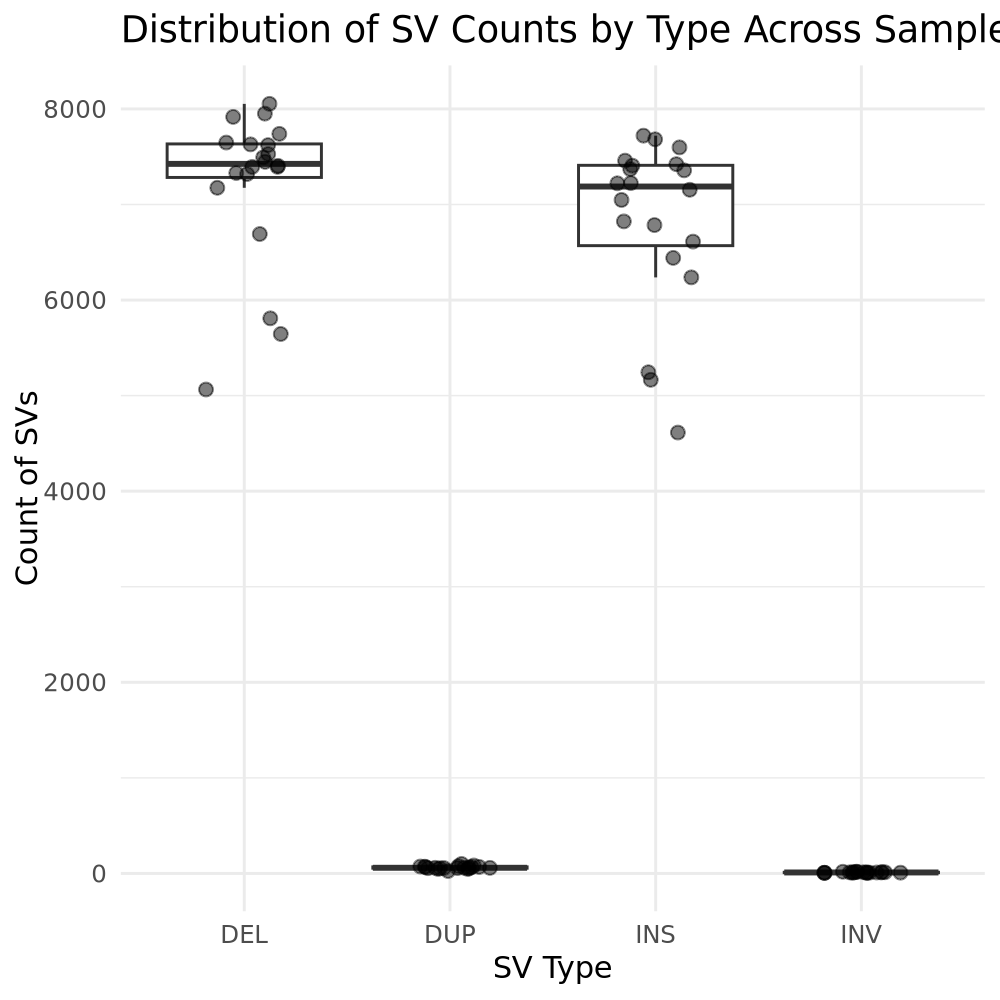

In [24]:
# Load libraries
library(dplyr)
library(tidyr)
library(ggplot2)

# Step 1: Aggregate counts
sv_counts <- data_filtered %>%
  group_by(filename, type) %>%
  summarise(count = n(), .groups = "drop")

# Step 2: Include zeros for missing combinations
sv_counts_complete <- sv_counts %>%
  complete(filename, type, fill = list(count = 0))

# Step 3: Create boxplot
ggplot(sv_counts_complete, aes(x = type, y = count)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.5, size = 2) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  theme_minimal()

# Step 4: Statistical tests
# Friedman test
friedman_result <- friedman.test(count ~ type | filename, data = sv_counts_complete)
print(friedman_result)

# If Friedman test is significant, proceed with pairwise comparisons
if (friedman_result$p.value < 0.05) {
  sv_counts_wide <- sv_counts_complete %>%
    pivot_wider(names_from = type, values_from = count)
  types <- colnames(sv_counts_wide)[-1]
  pairs <- combn(types, 2, simplify = FALSE)
  p_values <- sapply(pairs, function(pair) {
    wilcox.test(sv_counts_wide[[pair[1]]], sv_counts_wide[[pair[2]]], paired = TRUE)$p.value
  })
  p_adjusted <- p.adjust(p_values, method = "bonferroni")
  results <- data.frame(
    Comparison = sapply(pairs, function(p) paste(p[1], "vs", p[2])),
    P_Value_Adjusted = p_adjusted
  )
  print(results)
}

Warning message in wilcox.test.default(c(66, 59, 58, 54, 72, 25, 65, 56, 47, 47, :
“cannot compute exact p-value with ties”


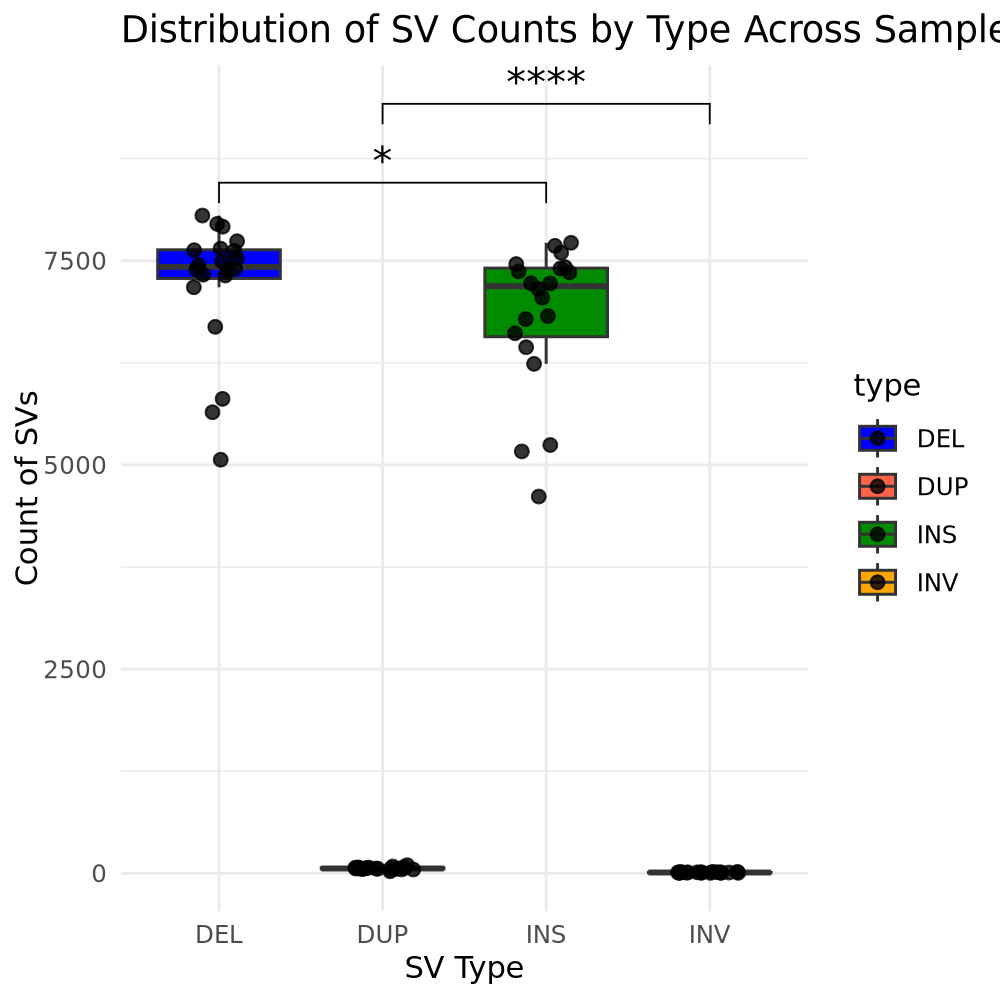

In [25]:
options(repr.plot.width = 5, repr.plot.height = 5, repr.plot.res = 200)

# Define specific colors for each SV type
colors <- c("DEL" = "blue", "DUP" = "tomato", "INV" = "orange", "INS" = "green4")

# Install and load ggpubr if you haven't already
# install.packages("ggpubr")
library(ggpubr)

# Define pairwise comparisons (all six pairs for four groups)
comparisons <- list(
  #c("DEL", "DUP"), 
  #c("DEL", "INV"), 
  c("DEL", "INS"),
  c("DUP", "INV") 
  #c("DUP", "INS"), 
  #c("INV", "INS")
)

ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.2, alpha = 0.8, size = 2) +
  stat_compare_means(comparisons = comparisons, method = "wilcox.test", label = "p.signif", size = 5) +
  labs(x = "SV Type", y = "Count of SVs", 
       title = "Distribution of SV Counts by Type Across Samples") +
  scale_fill_manual(values = colors) +
  theme_minimal()

#ggsave("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/Distribution_sv_tpes_v2.pdf", plot = sv_counts_complete, height = 6, width = 14)


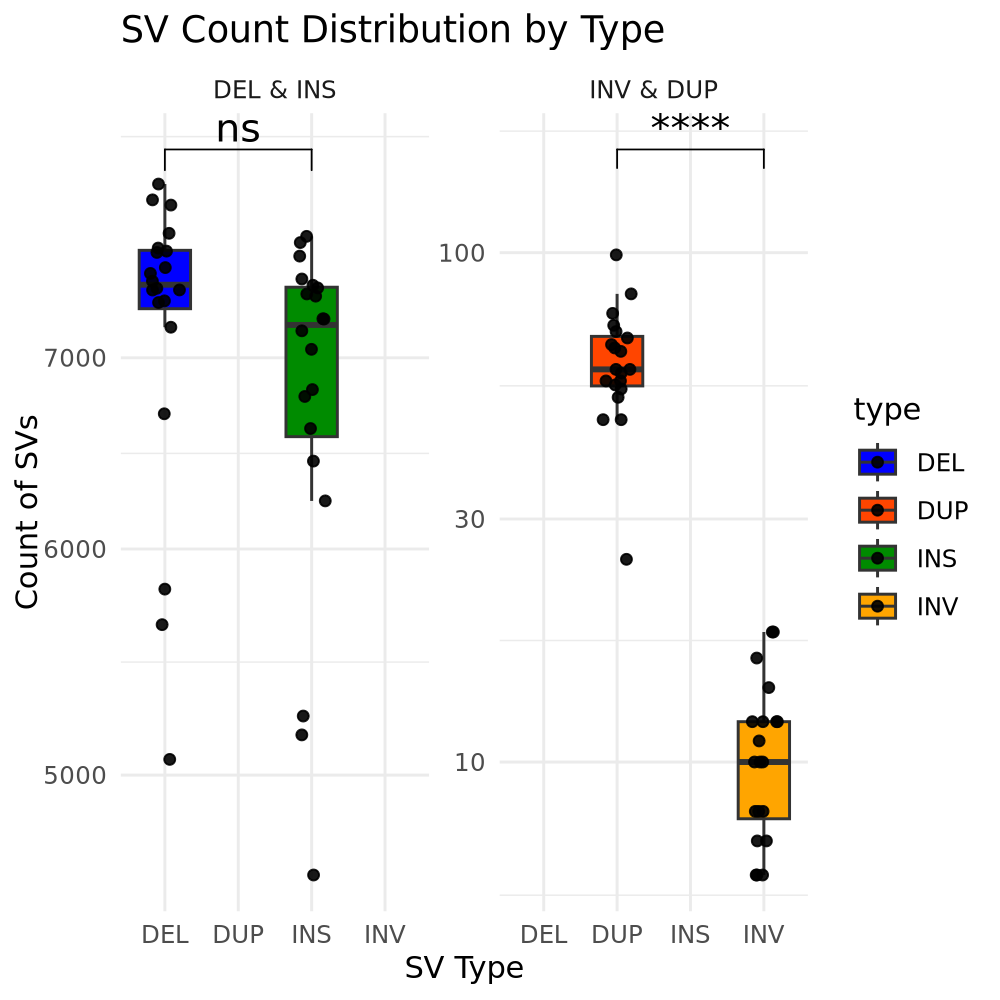

In [26]:
library(ggplot2)
library(ggpubr)

# Define colors for SV types
colors <- c("DEL" = "blue", "DUP" = "orangered", "INV" = "orange", "INS" = "green4")

# Define only the required pairwise comparisons
comparisons <- list(
  c("DEL", "INS"),
  c("INV", "DUP")
)

# Grouping for facet separation
sv_counts_complete$scale_group <- ifelse(sv_counts_complete$type %in% c("DEL", "INS"), "DEL & INS", "INV & DUP")

# Create the plot
ggplot(sv_counts_complete, aes(x = type, y = count, fill = type)) +
  geom_boxplot(outlier.shape = NA, width = 0.7) +  # Boxplot for distributions
  geom_jitter(width = 0.2, alpha = 0.9, size = 1.5) +  # Jitter points for low-count SVs
  stat_compare_means(comparisons = comparisons, method = "t.test", label = "p.signif", size = 5) +  # Wilcoxon test
  labs(x = "SV Type", y = "Count of SVs", title = "SV Count Distribution by Type") +
  scale_fill_manual(values = colors) +
  theme_minimal() +
  facet_wrap(~scale_group, scales = "free_y") +  # Separate DEL/INS and INV/DUP for clarity
  scale_y_log10()  # Log scale to make low-count SVs (DUP) visible



In [29]:
head(sv_counts_complete)

filename,type,count,scale_group
<chr>,<chr>,<int>,<chr>
2436A_run3,DEL,7404,DEL & INS
2436A_run3,DUP,66,INV & DUP
2436A_run3,INS,7154,DEL & INS
2436A_run3,INV,12,INV & DUP
2436A_run5,DEL,7446,DEL & INS
2436A_run5,DUP,59,INV & DUP


In [30]:
library(dplyr)

#pdf("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/sv_length_distr_barplot_v3.pdf",
   # height = 3, width = 5)

# Plot using transformed data
bar_plot <- ggplot(sv_counts_log, aes(x = type, y = log_count, fill = type)) +
  geom_bar(stat = "summary", fun = mean, width = 0.7) +
  geom_errorbar(stat = "summary", fun.data = mean_se, width = 0.2) +
  scale_fill_manual(values = c("DEL" = "blue", "DUP" = "tomato", "INV" = "orange", "INS" = "green4")) +
  labs(x = "SV Type", y = "Log10(Count)", title = "SV Count Distribution (Log10 Scale)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  stat_compare_means(aes(y = log_count),
                     comparisons = list(c("DEL", "DUP"), c("DEL", "INS"),
                                        c("DUP", "INV"), c("INS", "INV")),
                     method = "t.test", label = "p.signif", tip.length = 0.05)

print(bar_plot)  # <--- This is essential!

#dev.off()


ERROR: Error: object 'sv_counts_log' not found


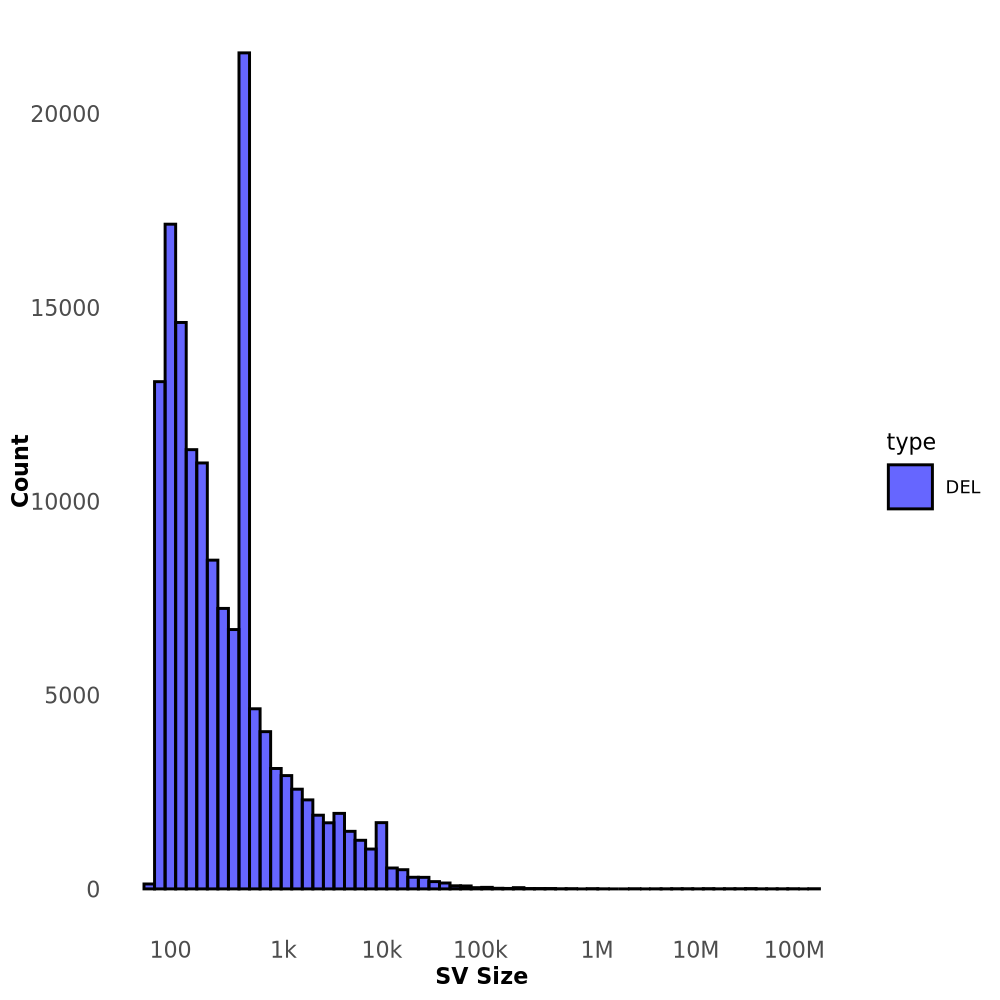

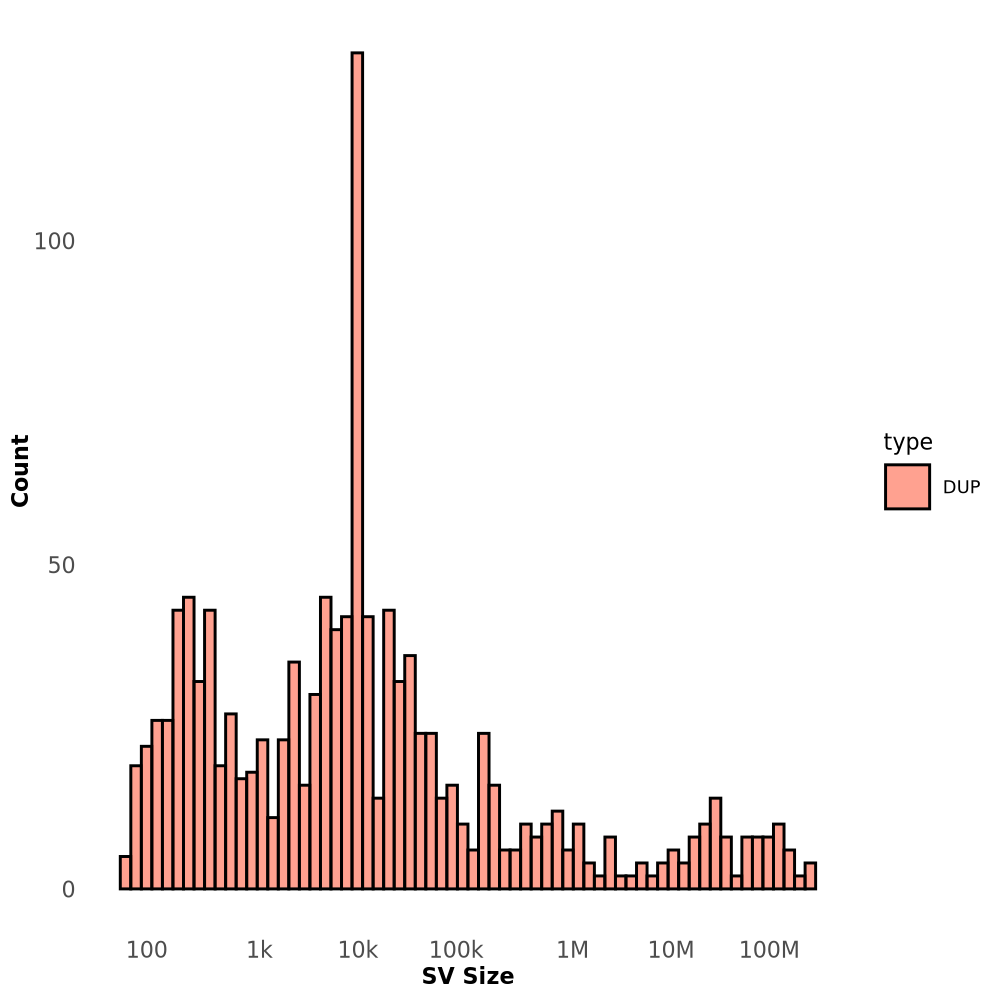

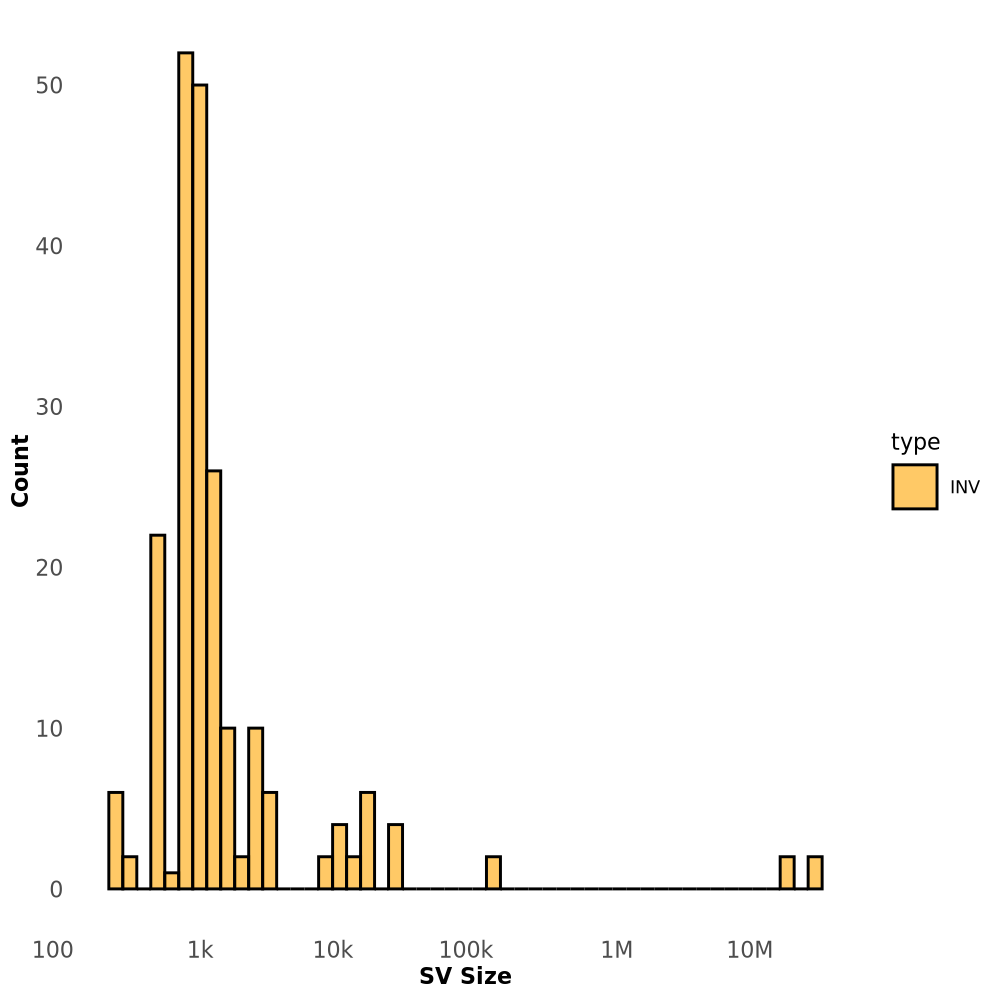

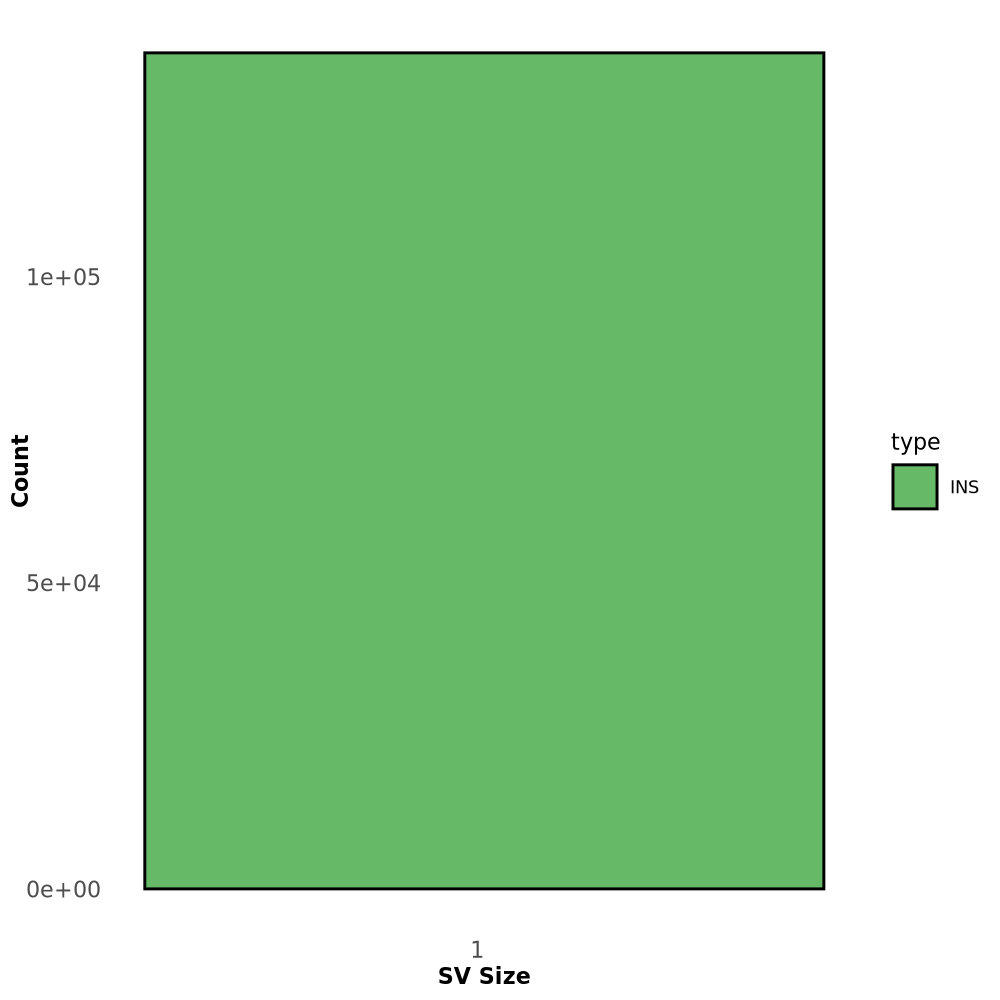

In [31]:
plot_sv_histogram <- function(sv_type, color) {
  ggplot(data %>% filter(type == sv_type), 
         aes(x = size, fill = type)) +
    geom_histogram(binwidth = 0.1, alpha = 0.6, position = "identity", color = "black") +  # Histogram with binwidth of 0.1
    scale_x_continuous(trans = "log10", 
                       breaks = c(1, 10, 100, 1000, 10000, 100000, 1000000, 10000000, 100000000),  # Log scale breaks up to 10M
                       labels = function(x) {
                         # Handle custom labels based on magnitude
                         sapply(x, function(val) {
                           if (is.na(val)) {
                             return(NA)  # Return NA if the value is not numeric
                           } else if (val < 1000) {
                             return(paste0(val))  # No scaling for values < 1k
                           } else if (val >= 1000 && val < 10000) {
                             return(paste0(val / 1000, "k"))  # Values between 1k and 10k
                           } else if (val >= 10000 && val < 100000) {
                             return(paste0(val / 1000, "k"))  # Values between 10k and 100k
                           } else if (val >= 100000 && val < 1000000) {
                             return(paste0(val / 1000, "k"))  # Values between 100k and 1M
                           } else if (val >= 1000000 && val < 10000000) {
                             return(paste0(val / 1000000, "M"))  # Values between 1M and 10M
                           } else {
                             return(paste0(val / 1000000, "M"))  # For values >= 10M
                           }
                         })
                       }) +  # Custom labels for x-axis based on size
    scale_fill_manual(values = setNames(color, sv_type)) +
    labs(x = "SV Size", y = "Count") +
    theme_minimal(base_size = 8) +  # Clean theme with larger text
    theme(axis.text.x = element_text(angle = 0, hjust = 1),  # Angle x-axis labels for better readability
          axis.title.x = element_text(face = "bold"),  # Bold x-axis label
          axis.title.y = element_text(face = "bold"),  # Bold y-axis label
          axis.text = element_text(size = 8),  # Increase text size
          panel.grid.major = element_blank(),  # Remove major grid lines for a cleaner look
          panel.grid.minor = element_blank(),  # Remove minor grid lines
          plot.title = element_text(face = "bold", hjust = 0.5))  # Centered title
}
#options(repr.plot.width = 5, repr.plot.height = 2, repr.plot.res = 200)

#pdf("/home/mjehangir/glioma_manuscript/manuscript_data/plots_f1/plot_sv_histogram_v2.pdf", height = 6, width = 14)

# Call your plotting function for each SV type
plot_sv_histogram("DEL", "blue")  # Deletions
plot_sv_histogram("DUP", "tomato")   # Duplications
plot_sv_histogram("INV", "orange") # Inversions
plot_sv_histogram("INS", "green4") # Insertions

#dev.off()  # Close the PDF device
